In [1]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom

from probjax.core import log_potential_fn, joint_sample, intervene
from probjax.core.custom_primitives.random_variable import rv 
from probjax.distributions import Normal


from probjax.inference.mcmc import MCMC 
from probjax.inference.transition_kernels import GaussianKernel, UniformKernel
from probjax.utils.jaxutils import flatten_fun

In [2]:
def f(key):
    key1, key2, key3 = jrandom.split(key, 3)
    z1 = rv(Normal(0, 1), "z1")(key1)
    z2  =z1 ** 2
    z3 = rv(Normal(z2, 1), "z2")(key2)
    z4 = z3 ** 3
    z5 = rv(Normal(z4, 0.1), "x")(key3)
    return z5

In [3]:
conditional = intervene(f, {"x": jnp.array(1.0)})

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [4]:
x = f(jrandom.PRNGKey(0))
sampler = joint_sample(conditional)
potential_fn = log_potential_fn(conditional, jrandom.PRNGKey(1))

In [5]:
jaxpr = jax.make_jaxpr(f)(jrandom.PRNGKey(0))

In [8]:
init_samples =  sampler(jrandom.PRNGKey(0))
flat_args,  in_tree = jax.tree_util.tree_flatten(init_samples)

In [9]:
mcmc = MCMC(UniformKernel(), potential_fn, init_samples)

In [14]:
@jax.vmap 
def mcmc_sampling(key):
    return mcmc.run(key,5000)

samples = mcmc_sampling(jrandom.split(jrandom.PRNGKey(0), 1000))

(array([ 1.,  0.,  2.,  1.,  0.,  1.,  2.,  8.,  5.,  3.,  8.,  5., 18.,
        17., 20., 17., 21., 32., 28., 28., 40., 34., 46., 52., 48., 36.,
        57., 45., 56., 50., 59., 40., 39., 30., 29., 24., 25., 24., 12.,
        14.,  6.,  5.,  2.,  2.,  2.,  1.,  1.,  0.,  1.,  3.]),
 array([0.885, 0.889, 0.893, 0.898, 0.902, 0.906, 0.91 , 0.915, 0.919,
        0.923, 0.928, 0.932, 0.936, 0.941, 0.945, 0.949, 0.953, 0.958,
        0.962, 0.966, 0.971, 0.975, 0.979, 0.984, 0.988, 0.992, 0.997,
        1.001, 1.005, 1.009, 1.014, 1.018, 1.022, 1.027, 1.031, 1.035,
        1.04 , 1.044, 1.048, 1.052, 1.057, 1.061, 1.065, 1.07 , 1.074,
        1.078, 1.083, 1.087, 1.091, 1.095, 1.1  ]),
 <BarContainer object of 50 artists>)

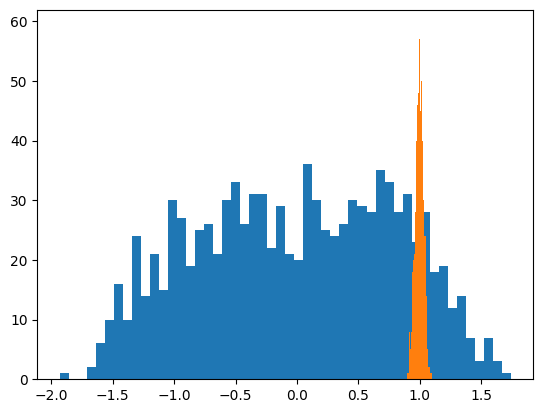

In [15]:
import matplotlib.pyplot as plt
plt.hist(samples["z1"], bins=50)
plt.hist(samples["z2"], bins=50)